# Conditional GASP Sensitivity Analysis

This notebook provides sensitivity analysis for Conditional GASP, focusing on how training flip angle (α) affects performance across different T1/T2 ratios.

## Key Analysis:
- **Training α vs Evaluation T1/T2 Ratio** - How flip angle during training affects performance across tissues
- **Profile Comparison** - Different spectral profiles (Gaussian, Square, Bandpass)
- **Model Management** - Train and save models for each alpha, reuse if already exists

## Approach:
For each combination of (alpha, profile, bw, offset):
1. Train a Conditional GASP model (or load if exists)
2. Evaluate on tissues with varying T1/T2 ratios
3. Compare MSE across the parameter space

In [1]:
import sys
from pathlib import Path
import time

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, ticker
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch

# GASP imports
from gasp import responses, sampling
from gasp.simulation import SSFPParams
from gasp.ml.conditional_gasp import ConditionalGASP, design_matrix_torch
from gasp.ml.data_generator import generate_signal_simple, generate_training_batch
from gasp.ml.trainer import train_conditional_gasp

# Set default plot style
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Device configuration - prioritize MPS (Apple Silicon GPU) > CUDA > CPU
if torch.backends.mps.is_available():
    device = 'mps'
    print(f"Using device: {device} (Apple Silicon GPU)")
    print(f"MPS built: {torch.backends.mps.is_built()}")
elif torch.cuda.is_available():
    device = 'cuda'
    print(f"Using device: {device}")
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
else:
    device = 'cpu'
    print(f"Using device: {device}")
    print("Note: GPU acceleration not available. Training will be slower.")

# Set default dtype to float32 for MPS compatibility
torch.set_default_dtype(torch.float32)
print(f"Default tensor dtype: {torch.get_default_dtype()}")

print("Conditional GASP Sensitivity Analysis Notebook loaded successfully!")

Using device: mps (Apple Silicon GPU)
MPS built: True
Default tensor dtype: torch.float32
Conditional GASP Sensitivity Analysis Notebook loaded successfully!


## Configuration Parameters

In [2]:
# Simulation parameters
WIDTH = 128
N_PCS = 8
N_TRS = 3
TRS_BASE = [5e-3, 10e-3, 15e-3]

# Model parameters
METHOD = 'affine'
LATENT_DIM = 16

# Training parameters
N_EPOCHS = 50
BATCH_SIZE = 32
N_BATCHES_PER_EPOCH = 50
LEARNING_RATE = 1e-3
LAMBDA_L2 = 1e-3
LAMBDA_SMOOTH = 1e-4
NOISE_SIGMA = 0.005

# Sensitivity analysis parameters
ALPHA_VALUES = np.arange(5, 95, 5)  # 5, 10, 15, ..., 90 degrees
N_RATIO = 50  # Number of T1/T2 ratio values to evaluate
RATIO_MIN = 0.5
RATIO_MAX = 20

# Reference tissue types with their T1/T2 ratios
TISSUE_TYPES = {
    'Water': {'T1': 4.0, 'T2': 2.0, 'ratio': 2.0},
    'Fat': {'T1': 0.25, 'T2': 0.07, 'ratio': 3.57},
    'White Matter': {'T1': 0.6, 'T2': 0.08, 'ratio': 7.5},
    'Gray Matter': {'T1': 0.9, 'T2': 0.1, 'ratio': 9.0},
    'Liver': {'T1': 0.5, 'T2': 0.04, 'ratio': 12.5},
    'Muscle': {'T1': 0.9, 'T2': 0.05, 'ratio': 18.0},
    'Tendon': {'T1': 0.4, 'T2': 0.005, 'ratio': 80.0},
}

# Model save directory
MODEL_DIR = project_root / 'models' / 'sensitivity'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Alpha values to test: {len(ALPHA_VALUES)} ({ALPHA_VALUES[0]}° to {ALPHA_VALUES[-1]}°)")
print(f"Evaluation grid: {N_RATIO} T1/T2 ratios from {RATIO_MIN} to {RATIO_MAX}")
print(f"Model directory: {MODEL_DIR}")

Alpha values to test: 18 (5° to 90°)
Evaluation grid: 50 T1/T2 ratios from 0.5 to 20
Model directory: /Users/michael/projects/mri/GASP/models/sensitivity


## Helper Functions

In [3]:
def create_acquisition_params(alpha_deg: float, n_pcs: int = N_PCS, n_TRs: int = N_TRS):
    """
    Create acquisition parameters with fixed flip angle.
    
    Args:
        alpha_deg: Flip angle in degrees
        n_pcs: Number of phase cycles
        n_TRs: Number of TRs
    
    Returns:
        SSFPParams object
    """
    TRs = TRS_BASE[:n_TRs]
    pcs = np.linspace(0, 2 * np.pi, n_pcs, endpoint=False)
    
    length = n_pcs * n_TRs
    alpha_rad = np.deg2rad(alpha_deg)
    alpha_list = [alpha_rad] * length
    TR_list = []
    pc_list = []
    for tr in TRs:
        for pc in pcs:
            TR_list.append(tr)
            pc_list.append(pc)
    
    return SSFPParams(length, alpha_list, TR_list, pc_list)


def get_model_name(method: str, profile_type: str, bw: float, offset: float, alpha_deg: float) -> str:
    """
    Generate standardized model filename.
    
    Format: conditional_gasp_{method}_{profile}_{bw}_{offset}_alpha{alpha}.pt
    
    Args:
        method: GASP method (e.g., 'affine')
        profile_type: Profile type (e.g., 'gaussian', 'square', 'bandpass')
        bw: Bandwidth parameter
        offset: Offset/shift parameter
        alpha_deg: Flip angle in degrees
    
    Returns:
        Filename string
    """
    # Format bw and offset to avoid floating point issues in filename
    bw_str = f"{bw:.2f}".replace('.', 'p')
    offset_str = f"{offset:.2f}".replace('.', 'p').replace('-', 'n')
    alpha_str = f"{int(alpha_deg):02d}"
    
    return f"conditional_gasp_{method}_{profile_type}_bw{bw_str}_off{offset_str}_alpha{alpha_str}.pt"


def load_or_train_model(
    alpha_deg: float,
    target_profile: np.ndarray,
    profile_type: str,
    bw: float,
    offset: float,
    method: str = METHOD,
    force_retrain: bool = False,
    verbose: bool = True
) -> ConditionalGASP:
    """
    Load existing model or train new one if not found.
    
    Args:
        alpha_deg: Training flip angle in degrees
        target_profile: Target spectral profile
        profile_type: Type of profile ('gaussian', 'square', 'bandpass')
        bw: Bandwidth of profile
        offset: Offset/shift of profile
        method: GASP method
        force_retrain: If True, retrain even if model exists
        verbose: Print progress messages
    
    Returns:
        Trained ConditionalGASP model
    """
    model_name = get_model_name(method, profile_type, bw, offset, alpha_deg)
    model_path = MODEL_DIR / model_name
    
    # Try to load existing model
    if model_path.exists() and not force_retrain:
        if verbose:
            print(f"  Loading existing model: {model_name}")
        model = ConditionalGASP.load(model_path, device=device)
        model.eval()
        return model
    
    # Train new model
    if verbose:
        print(f"  Training new model: {model_name}")
    
    # Create acquisition parameters with this alpha
    params = create_acquisition_params(alpha_deg)
    
    # Start timer
    start_time = time.time()
    
    # Convert target profile to float32
    target_profile_f32 = target_profile.astype(np.float32)
    
    # Train model
    model, history = train_conditional_gasp(
        params=params,
        target_profile=target_profile_f32,
        n_epochs=N_EPOCHS,
        batch_size=BATCH_SIZE,
        n_batches_per_epoch=N_BATCHES_PER_EPOCH,
        learning_rate=LEARNING_RATE,
        width=WIDTH,
        latent_dim=LATENT_DIM,
        method=method,
        t1_range=(0.1, 4.0),
        t2_t1_ratio_range=(0.01, 0.5),
        noise_sigma=NOISE_SIGMA,
        lambda_l2=LAMBDA_L2,
        lambda_smooth=LAMBDA_SMOOTH,
        verbose=True,
        save_path=model_path,
        save_best=True,
        device=device,
    )
    
    # Calculate elapsed time
    elapsed_time = time.time() - start_time
    minutes = int(elapsed_time // 60)
    seconds = int(elapsed_time % 60)
    
    if verbose:
        print(f"    Training completed in {minutes}m {seconds}s")
        print(f"    Saved to: {model_path.name}")
    
    return model


def evaluate_model_on_tissue(
    model: ConditionalGASP,
    alpha_deg: float,
    T1: float,
    T2: float,
    target_profile: np.ndarray
) -> float:
    """
    Evaluate a trained model on a specific tissue type.
    
    Args:
        model: Trained ConditionalGASP model
        alpha_deg: Flip angle to use for evaluation (should match training)
        T1: T1 relaxation time (seconds)
        T2: T2 relaxation time (seconds)
        target_profile: Target spectral profile
    
    Returns:
        MSE between output and target
    """
    # Create acquisition params with same alpha as training
    params = create_acquisition_params(alpha_deg)
    
    # Generate signal for this tissue
    signal = generate_signal_simple(T1, T2, params, width=WIDTH)
    
    # Convert to torch with explicit float32 dtype for MPS compatibility
    if signal.dtype == np.complex128:
        # Convert complex128 to complex64
        signal = signal.astype(np.complex64)
    
    signal_t = torch.from_numpy(signal).to(device)
    
    model.eval()
    with torch.no_grad():
        A, _ = model(signal_t, return_latent=True)
        Phi = design_matrix_torch(signal_t, model.method)
        output = (Phi * A).sum(dim=-1).abs().cpu().numpy()
    
    # Ensure target profile is float32
    target_profile_f32 = target_profile.astype(np.float32)
    
    # Compute MSE
    mse = np.mean((output.astype(np.float32) - target_profile_f32) ** 2)
    return float(mse)


print("Helper functions defined.")

Helper functions defined.


## Sensitivity Analysis Function

In [4]:
def sensitivity_analysis_conditional(
    target_profile: np.ndarray,
    profile_type: str,
    bw: float,
    offset: float,
    alpha_values: np.ndarray,
    ratio_min: float = RATIO_MIN,
    ratio_max: float = RATIO_MAX,
    n_ratio: int = N_RATIO,
    method: str = METHOD,
    force_retrain: bool = False
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Perform sensitivity analysis: Training α vs Evaluation T1/T2 ratio.
    
    For each flip angle α:
      1. Train (or load) a Conditional GASP model
      2. Evaluate on tissues with varying T1/T2 ratios
    
    Args:
        target_profile: Target spectral profile
        profile_type: Type of profile ('gaussian', 'square', 'bandpass')
        bw: Bandwidth parameter
        offset: Offset parameter
        alpha_values: Array of flip angles to test (degrees)
        ratio_min: Minimum T1/T2 ratio
        ratio_max: Maximum T1/T2 ratio
        n_ratio: Number of ratio values
        method: GASP method
        force_retrain: If True, retrain all models
    
    Returns:
        mse_2d: (n_alpha, n_ratio) MSE matrix
        alphas: flip angle array (degrees)
        ratios: T1/T2 ratio array
    """
    n_alpha = len(alpha_values)
    ratios = np.linspace(ratio_min, ratio_max, n_ratio)
    T2_base = 0.1  # Fixed T2 for evaluation
    
    mse_2d = np.zeros((n_alpha, n_ratio))
    
    print(f"Running sensitivity analysis for {profile_type} profile (bw={bw}, offset={offset})")
    print(f"Testing {n_alpha} alpha values x {n_ratio} T1/T2 ratios = {n_alpha * n_ratio} evaluations")
    print()
    
    # Train/load models and evaluate for each alpha
    for i, alpha_deg in enumerate(alpha_values):
        print(f"[{i+1}/{n_alpha}] Alpha = {alpha_deg}°")
        
        # Load or train model for this alpha
        model = load_or_train_model(
            alpha_deg=alpha_deg,
            target_profile=target_profile,
            profile_type=profile_type,
            bw=bw,
            offset=offset,
            method=method,
            force_retrain=force_retrain,
            verbose=True
        )
        
        # Evaluate on all T1/T2 ratios
        for j, ratio in enumerate(ratios):
            T1_eval = T2_base * ratio
            mse = evaluate_model_on_tissue(
                model=model,
                alpha_deg=alpha_deg,
                T1=T1_eval,
                T2=T2_base,
                target_profile=target_profile
            )
            mse_2d[i, j] = mse
        
        print(f"    Mean MSE across ratios: {mse_2d[i].mean():.6f}")
        print()
    
    return mse_2d, alpha_values, ratios


print("Sensitivity analysis function defined.")

Sensitivity analysis function defined.


## Plotting Functions

In [19]:
def plot_heatmap_alpha_vs_ratio(
    mse_2d: np.ndarray,
    alphas: np.ndarray,
    ratios: np.ndarray,
    title: str = '',
    cmap: str = 'viridis_r',
    use_log: bool = True,
    ax = None,
    show_tissue_lines: bool = True,
    vmin: float = None,
    vmax: float = None
):
    """
    Plot heatmap of trained α vs T1/T2 ratio.
    
    Args:
        vmin: Minimum value for color scale (optional, for unified scales)
        vmax: Maximum value for color scale (optional, for unified scales)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
    
    X, Y = np.meshgrid(ratios, alphas)
    
    # Determine min/max for color scale
    if vmin is None:
        vmin = mse_2d.min()
    if vmax is None:
        vmax = mse_2d.max()
    
    if use_log:
        # Use log scale for better visualization
        levels = np.logspace(np.log10(vmin + 1e-12), np.log10(vmax), 25)
        cs = ax.contourf(X, Y, mse_2d, levels=levels, locator=ticker.LogLocator(), 
                         cmap=cmap, extend='both')
    else:
        cs = ax.contourf(X, Y, mse_2d, levels=20, cmap=cmap, extend='both',
                         vmin=vmin, vmax=vmax)
    
    # Create colorbar with better tick formatting
    cbar = plt.colorbar(cs, ax=ax, label='MSE', format='%.2e')
    
    # Add tissue reference lines
    if show_tissue_lines:
        for name, props in TISSUE_TYPES.items():
            if props['ratio'] >= ratios.min() and props['ratio'] <= ratios.max():
                ax.axvline(props['ratio'], color='white', linestyle='--', alpha=0.7, linewidth=1)
                ax.text(props['ratio'] + 0.2, alphas.max() - 2, name,
                       color='white', fontsize=8, rotation=90, va='top')
    
    ax.set_xlabel('T1/T2 Ratio (Evaluation)', fontsize=12)
    ax.set_ylabel('Flip Angle α (Training, degrees)', fontsize=12)
    ax.set_title(title, fontsize=14)
    
    return ax


print("Plotting functions defined.")

Plotting functions defined.


---
## 1. Profile Comparison: Conditional GASP Sensitivity

This analysis compares different spectral profiles (Gaussian, Square, Bandpass) and shows how training flip angle affects Conditional GASP performance across tissue types.

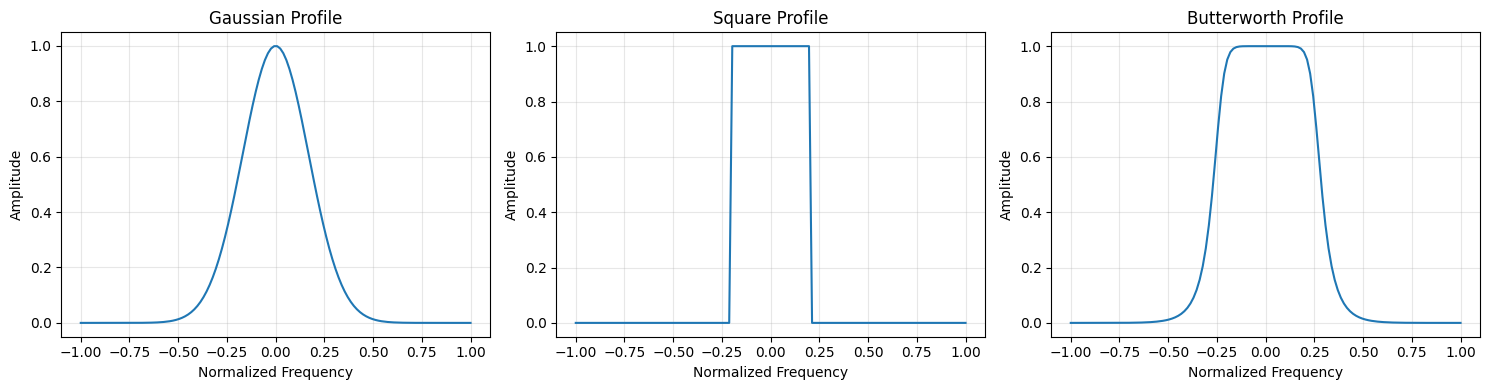

Target profiles created.


In [6]:
# Define target profiles to analyze
profiles_config = {
    'Gaussian': {
        'profile': responses.gaussian(WIDTH, bw=0.2, shift=0),
        'bw': 0.2,
        'offset': 0.0,
    },
    'Square': {
        'profile': responses.square(WIDTH, bw=0.2, shift=0),
        'bw': 0.2,
        'offset': 0.0,
    },
    'Butterworth': {
        'profile': responses.bandpass(WIDTH, bw=0.25, shift=0, type='butterworth'),
        'bw': 0.25,
        'offset': 0.0,
    },
}

# Visualize profiles
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
freq_axis = np.linspace(-1, 1, WIDTH)

for idx, (name, config) in enumerate(profiles_config.items()):
    axes[idx].plot(freq_axis, config['profile'])
    axes[idx].set_xlabel('Normalized Frequency')
    axes[idx].set_ylabel('Amplitude')
    axes[idx].set_title(f'{name} Profile')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Target profiles created.")

### 1.1 Run Sensitivity Analysis

**Note:** This cell will train multiple neural network models (one for each alpha value). Set `FORCE_RETRAIN=True` to retrain all models, or `False` to reuse existing models.

In [7]:
# Set to True to force retraining of all models
FORCE_RETRAIN = False

# Run sensitivity analysis for each profile
results_profiles = {}

for name, config in profiles_config.items():
    print("=" * 70)
    print(f"Processing {name} Profile")
    print("=" * 70)
    
    mse_2d, alphas, ratios = sensitivity_analysis_conditional(
        target_profile=config['profile'],
        profile_type=name.lower(),
        bw=config['bw'],
        offset=config['offset'],
        alpha_values=ALPHA_VALUES,
        method=METHOD,
        force_retrain=FORCE_RETRAIN
    )
    
    results_profiles[name] = {
        'mse_2d': mse_2d,
        'alphas': alphas,
        'ratios': ratios,
        'mse_1d': mse_2d.mean(axis=1),  # Mean across ratios
    }
    
    print(f"\nCompleted {name} profile")
    print(f"Overall mean MSE: {mse_2d.mean():.6f}")
    print()

print("\n" + "=" * 70)
print("Sensitivity analysis complete!")
print("=" * 70)

Processing Gaussian Profile
Running sensitivity analysis for gaussian profile (bw=0.2, offset=0.0)
Testing 18 alpha values x 50 T1/T2 ratios = 900 evaluations

[1/18] Alpha = 5°
  Loading existing model: conditional_gasp_affine_gaussian_bw0p20_off0p00_alpha05.pt
    Mean MSE across ratios: 0.000015

[2/18] Alpha = 10°
  Loading existing model: conditional_gasp_affine_gaussian_bw0p20_off0p00_alpha10.pt
    Mean MSE across ratios: 0.000042

[3/18] Alpha = 15°
  Loading existing model: conditional_gasp_affine_gaussian_bw0p20_off0p00_alpha15.pt
    Mean MSE across ratios: 0.000038

[4/18] Alpha = 20°
  Loading existing model: conditional_gasp_affine_gaussian_bw0p20_off0p00_alpha20.pt
    Mean MSE across ratios: 0.000028

[5/18] Alpha = 25°
  Loading existing model: conditional_gasp_affine_gaussian_bw0p20_off0p00_alpha25.pt
    Mean MSE across ratios: 0.000027

[6/18] Alpha = 30°
  Loading existing model: conditional_gasp_affine_gaussian_bw0p20_off0p00_alpha30.pt
    Mean MSE across ratios:

Epochs: 100%|██████████| 50/50 [02:26<00:00,  2.93s/it]


Training complete. Best val_loss: 0.0000
    Training completed in 2m 27s
    Saved to: conditional_gasp_affine_square_bw0p20_off0p00_alpha05.pt
    Mean MSE across ratios: 0.000011

[2/18] Alpha = 10°
  Training new model: conditional_gasp_affine_square_bw0p20_off0p00_alpha10.pt
Training on device: mps
Model parameters: 20,290


Epochs: 100%|██████████| 50/50 [02:27<00:00,  2.94s/it]


Training complete. Best val_loss: 0.0000
    Training completed in 2m 27s
    Saved to: conditional_gasp_affine_square_bw0p20_off0p00_alpha10.pt
    Mean MSE across ratios: 0.000043

[3/18] Alpha = 15°
  Training new model: conditional_gasp_affine_square_bw0p20_off0p00_alpha15.pt
Training on device: mps
Model parameters: 20,290


...

Training complete. Best val_loss: 0.0000
    Training completed in 34m 43s
    Saved to: conditional_gasp_affine_butterworth_bw0p25_off0p00_alpha80.pt
    Mean MSE across ratios: 0.000093

[17/18] Alpha = 85°
  Training new model: conditional_gasp_affine_butterworth_bw0p25_off0p00_alpha85.pt
Training on device: mps
Model parameters: 20,290


Epochs: 100%|██████████| 50/50 [43:01<00:00, 51.62s/it]   


Training complete. Best val_loss: 0.0000
    Training completed in 43m 1s
    Saved to: conditional_gasp_affine_butterworth_bw0p25_off0p00_alpha85.pt
    Mean MSE across ratios: 0.000167

[18/18] Alpha = 90°
  Training new model: conditional_gasp_affine_butterworth_bw0p25_off0p00_alpha90.pt
Training on device: mps
Model parameters: 20,290


Epochs: 100%|██████████| 50/50 [28:04<00:00, 33.69s/it]   

Training complete. Best val_loss: 0.0000
    Training completed in 28m 4s
    Saved to: conditional_gasp_affine_butterworth_bw0p25_off0p00_alpha90.pt
    Mean MSE across ratios: 0.000092


Completed Butterworth profile
Overall mean MSE: 0.000056


Sensitivity analysis complete!


### 1.2 Visualize Results: Training α vs Evaluation T1/T2 Heatmaps

Unified color scale: 3.701380e-07 to 6.373475e-03


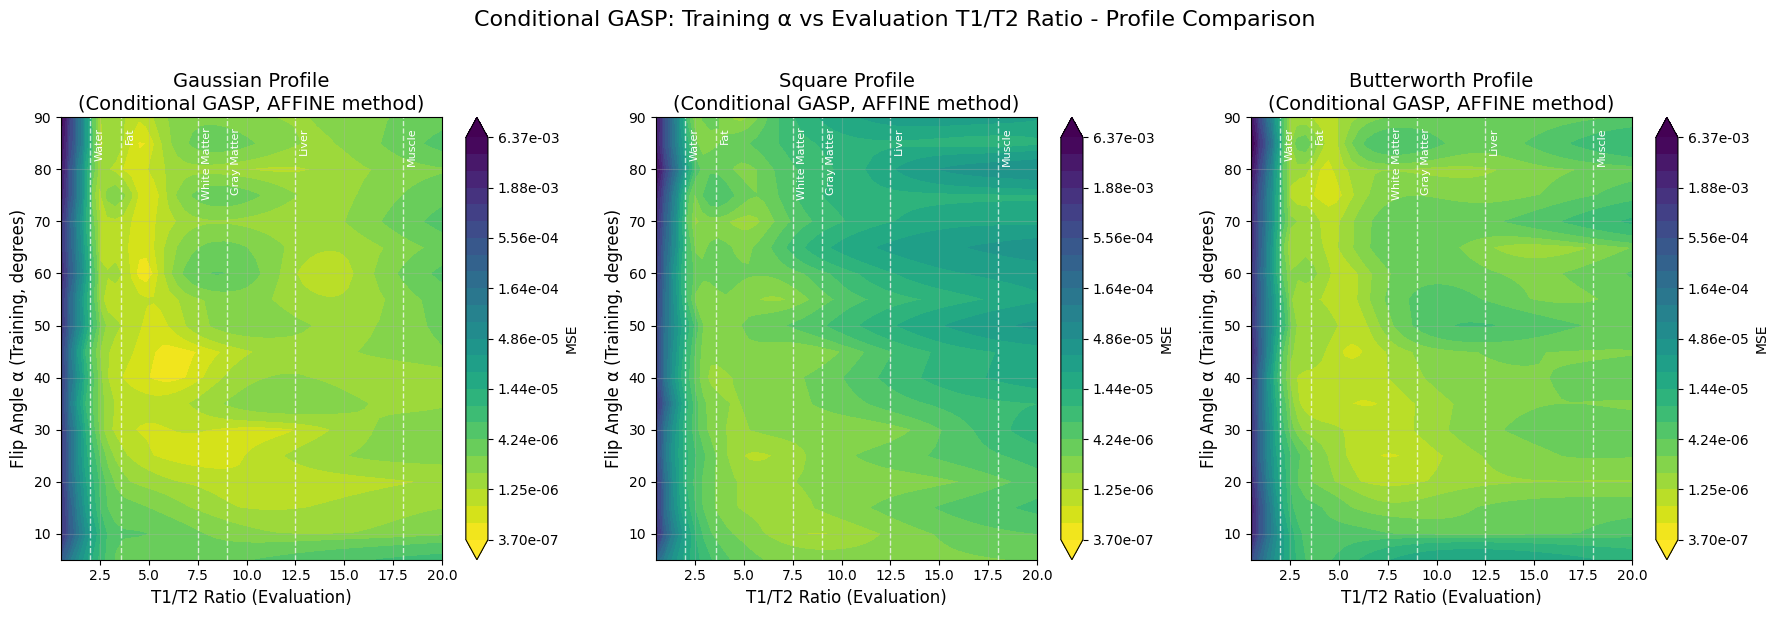

In [20]:
# Plot heatmaps for all profiles with unified color scale
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Calculate global min/max across all profiles for unified scale
global_min = min(res['mse_2d'].min() for res in results_profiles.values())
global_max = max(res['mse_2d'].max() for res in results_profiles.values())

print(f"Unified color scale: {global_min:.6e} to {global_max:.6e}")

for idx, (name, res) in enumerate(results_profiles.items()):
    plot_heatmap_alpha_vs_ratio(
        res['mse_2d'], res['alphas'], res['ratios'],
        title=f'{name} Profile\n(Conditional GASP, {METHOD.upper()} method)',
        ax=axes[idx],
        cmap='viridis_r',
        vmin=global_min,
        vmax=global_max
    )

plt.suptitle('Conditional GASP: Training α vs Evaluation T1/T2 Ratio - Profile Comparison',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
def get_model_output(
    profile_name: str,
    alpha_deg: float,
    T1: float,
    T2: float,
    target_profile: np.ndarray,
    profile_type: str,
    bw: float,
    offset: float
):
    """
    Get Conditional GASP output for specific parameters.
    
    Returns:
        output: cGASP output profile
        mse: Mean squared error
    """
    # Load model
    model = load_or_train_model(
        alpha_deg=alpha_deg,
        target_profile=target_profile,
        profile_type=profile_type,
        bw=bw,
        offset=offset,
        method=METHOD,
        force_retrain=False,
        verbose=False
    )
    
    # Create acquisition params
    params = create_acquisition_params(alpha_deg)
    
    # Generate signal
    signal = generate_signal_simple(T1, T2, params, width=WIDTH)
    if signal.dtype == np.complex128:
        signal = signal.astype(np.complex64)
    
    signal_t = torch.from_numpy(signal).to(device)
    
    # Get model output
    model.eval()
    with torch.no_grad():
        A, _ = model(signal_t, return_latent=True)
        Phi = design_matrix_torch(signal_t, model.method)
        output = (Phi * A).sum(dim=-1).abs().cpu().numpy()
    
    # Compute MSE
    mse = np.mean((output.astype(np.float32) - target_profile.astype(np.float32)) ** 2)
    
    return output, mse


# Create figure for best/worst examples with residual spread
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
freq_axis = np.linspace(-1, 1, WIDTH)

# Store statistics for table
residual_stats = {}

for row, (name, config) in enumerate(profiles_config.items()):
    res = results_profiles[name]
    target = config['profile']
    
    # Find best and worst (alpha, ratio) combinations
    best_idx = np.unravel_index(np.argmin(res['mse_2d']), res['mse_2d'].shape)
    worst_idx = np.unravel_index(np.argmax(res['mse_2d']), res['mse_2d'].shape)
    
    best_alpha = res['alphas'][best_idx[0]]
    best_ratio = res['ratios'][best_idx[1]]
    best_mse = res['mse_2d'][best_idx]
    
    worst_alpha = res['alphas'][worst_idx[0]]
    worst_ratio = res['ratios'][worst_idx[1]]
    worst_mse = res['mse_2d'][worst_idx]
    
    T2_base = 0.1
    
    # Get outputs for best case
    best_output, _ = get_model_output(
        name, best_alpha, best_ratio * T2_base, T2_base,
        target, name.lower(), config['bw'], config['offset']
    )
    
    # Get outputs for worst case
    worst_output, _ = get_model_output(
        name, worst_alpha, worst_ratio * T2_base, T2_base,
        target, name.lower(), config['bw'], config['offset']
    )
    
    # Calculate residuals for ALL (alpha, ratio) combinations
    print(f"Computing residual spread for {name} profile...")
    n_alpha = len(res['alphas'])
    n_ratio = len(res['ratios'])
    all_residuals = np.zeros((n_alpha * n_ratio, WIDTH))
    
    idx = 0
    for i, alpha_deg in enumerate(res['alphas']):
        for j, ratio in enumerate(res['ratios']):
            T1_eval = T2_base * ratio
            output, _ = get_model_output(
                name, alpha_deg, T1_eval, T2_base,
                target, name.lower(), config['bw'], config['offset']
            )
            all_residuals[idx] = output - target
            idx += 1
    
    # Calculate percentiles across all combinations for each frequency
    residual_median = np.median(all_residuals, axis=0)
    residual_p5 = np.percentile(all_residuals, 5, axis=0)
    residual_p25 = np.percentile(all_residuals, 25, axis=0)
    residual_p75 = np.percentile(all_residuals, 75, axis=0)
    residual_p95 = np.percentile(all_residuals, 95, axis=0)
    residual_min = np.min(all_residuals, axis=0)
    residual_max = np.max(all_residuals, axis=0)
    
    # Store statistics for table (using absolute values)
    abs_residuals = np.abs(all_residuals)
    residual_stats[name] = {
        'min': abs_residuals.min(),
        'max': abs_residuals.max(),
        'p5': np.percentile(abs_residuals, 5),
        'p95': np.percentile(abs_residuals, 95),
        'p25': np.percentile(abs_residuals, 25),
        'p75': np.percentile(abs_residuals, 75),
        'median': np.median(abs_residuals)
    }
    
    # Calculate residuals for best/worst
    best_residual = best_output - target
    worst_residual = worst_output - target
    
    # Plot best case (left column)
    ax_best = axes[row, 0]
    ax_best.plot(freq_axis, target, 'k-', linewidth=2, label='Target')
    ax_best.plot(freq_axis, best_output, 'b-', linewidth=1.5, label='cGASP', alpha=0.8)
    ax_best.fill_between(freq_axis, target, best_output, alpha=0.3, color='blue')
    ax_best.set_title(f'{name} - BEST Fit\nα={best_alpha:.0f}°, T1/T2={best_ratio:.2f}, MSE={best_mse:.2e}',
                     fontsize=10, fontweight='bold')
    ax_best.set_xlabel('Normalized Frequency')
    ax_best.set_ylabel('Amplitude')
    ax_best.legend(loc='upper right', fontsize=9)
    ax_best.grid(True, alpha=0.3)
    ax_best.set_ylim([-0.1, 1.1])
    
    # Plot worst case (middle column)
    ax_worst = axes[row, 1]
    ax_worst.plot(freq_axis, target, 'k-', linewidth=2, label='Target')
    ax_worst.plot(freq_axis, worst_output, 'r-', linewidth=1.5, label='cGASP', alpha=0.8)
    ax_worst.fill_between(freq_axis, target, worst_output, alpha=0.3, color='red')
    ax_worst.set_title(f'{name} - WORST Fit\nα={worst_alpha:.0f}°, T1/T2={worst_ratio:.2f}, MSE={worst_mse:.2e}',
                      fontsize=10, fontweight='bold')
    ax_worst.set_xlabel('Normalized Frequency')
    ax_worst.set_ylabel('Amplitude')
    ax_worst.legend(loc='upper right', fontsize=9)
    ax_worst.grid(True, alpha=0.3)
    ax_worst.set_ylim([-0.1, 1.1])
    
    # Plot residual spread (right column)
    ax_residual = axes[row, 2]
    
    # Plot percentile bands showing spread across ALL data
    ax_residual.fill_between(freq_axis, residual_min, residual_max, 
                             alpha=0.15, color='gray', label='Min-Max range')
    ax_residual.fill_between(freq_axis, residual_p5, residual_p95, 
                             alpha=0.3, color='steelblue', label='5th-95th percentile')
    ax_residual.fill_between(freq_axis, residual_p25, residual_p75, 
                             alpha=0.5, color='steelblue', label='25th-75th percentile')
    ax_residual.plot(freq_axis, residual_median, 'b-', linewidth=2, label='Median', alpha=0.9)
    ax_residual.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.7)
    
    # Calculate max residual magnitude for y-axis
    max_res = max(abs(residual_min).max(), abs(residual_max).max())
    ax_residual.set_ylim([-max_res*1.1, max_res*1.1])
    
    ax_residual.set_title(f'{name} - Residual Spread Across All α & T1/T2\n' + 
                         f'Median abs error: {np.median(np.abs(all_residuals)):.3f}, ' +
                         f'Max abs error: {np.abs(all_residuals).max():.3f}',
                         fontsize=10, fontweight='bold')
    ax_residual.set_xlabel('Normalized Frequency')
    ax_residual.set_ylabel('Residual Amplitude (cGASP - Target)')
    ax_residual.legend(loc='upper right', fontsize=8)
    ax_residual.grid(True, alpha=0.3)
    
    print(f"  Median abs residual: {np.median(np.abs(all_residuals)):.4f}")
    print(f"  95th percentile abs residual: {np.percentile(np.abs(all_residuals), 95):.4f}")
    print(f"  Max abs residual: {np.abs(all_residuals).max():.4f}\n")

plt.suptitle('Conditional GASP: Best/Worst Examples & Residual Distribution Across All Parameters', 
             fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

# Print residual statistics table
print("\n" + "=" * 100)
print("RESIDUAL STATISTICS (Absolute Values Across All α and T1/T2 Combinations)")
print("=" * 100)
print(f"{'Profile':<15} {'Min':<10} {'Max':<10} {'5th %ile':<10} {'95th %ile':<10} {'25th %ile':<10} {'75th %ile':<10} {'Median':<10}")
print("-" * 100)
for name, stats in residual_stats.items():
    print(f"{name:<15} {stats['min']:<10.4f} {stats['max']:<10.4f} {stats['p5']:<10.4f} "
          f"{stats['p95']:<10.4f} {stats['p25']:<10.4f} {stats['p75']:<10.4f} {stats['median']:<10.4f}")
print("=" * 100)
print(f"Note: Statistics computed from {n_alpha * n_ratio} combinations ({n_alpha} α values × {n_ratio} T1/T2 ratios)")
print("      Each combination evaluated across {WIDTH} frequency points")
print()

# Print summary
print("\nBest and Worst Fit Summary:")
print("=" * 90)
print(f"{'Profile':<12} {'Type':<6} {'α':<5} {'T1/T2':<7} {'MSE':<12} {'Max Residual':<12} {'Ratio'}")
print("=" * 90)
for name, config in profiles_config.items():
    res = results_profiles[name]
    best_idx = np.unravel_index(np.argmin(res['mse_2d']), res['mse_2d'].shape)
    worst_idx = np.unravel_index(np.argmax(res['mse_2d']), res['mse_2d'].shape)
    
    # Recalculate outputs to get residuals
    T2_base = 0.1
    best_output, _ = get_model_output(
        name, res['alphas'][best_idx[0]], res['ratios'][best_idx[1]] * T2_base, T2_base,
        config['profile'], name.lower(), config['bw'], config['offset']
    )
    worst_output, _ = get_model_output(
        name, res['alphas'][worst_idx[0]], res['ratios'][worst_idx[1]] * T2_base, T2_base,
        config['profile'], name.lower(), config['bw'], config['offset']
    )
    
    best_max_res = abs(best_output - config['profile']).max()
    worst_max_res = abs(worst_output - config['profile']).max()
    
    print(f"{name:<12} {'BEST':<6} {res['alphas'][best_idx[0]]:<5.0f} {res['ratios'][best_idx[1]]:<7.2f} {res['mse_2d'][best_idx]:<12.2e} {best_max_res:<12.3f}")
    print(f"{'':<12} {'WORST':<6} {res['alphas'][worst_idx[0]]:<5.0f} {res['ratios'][worst_idx[1]]:<7.2f} {res['mse_2d'][worst_idx]:<12.2e} {worst_max_res:<12.3f} {res['mse_2d'][worst_idx] / res['mse_2d'][best_idx]:.1f}x")
    print("-" * 90)

### 1.2b Best and Worst Fit Examples

For each profile, we show the best (lowest MSE) and worst (highest MSE) fits to visualize the quality of Conditional GASP performance.

In [12]:
# Inspect MSE statistics for each profile
for name, res in results_profiles.items():
    mse_2d = res['mse_2d']
    alphas = res['alphas']
    ratios = res['ratios']
    
    print(f"\n{'='*60}")
    print(f"{name} Profile - MSE Statistics")
    print(f"{'='*60}")
    print(f"Min MSE:  {mse_2d.min():.6e}")
    print(f"Max MSE:  {mse_2d.max():.6e}")
    print(f"Mean MSE: {mse_2d.mean():.6e}")
    print(f"Median:   {np.median(mse_2d):.6e}")
    
    # Find the worst performing combinations (white regions)
    print(f"\nTop 5 worst (alpha, T1/T2 ratio) combinations:")
    flat_indices = np.argsort(mse_2d.flatten())[-5:][::-1]
    for idx in flat_indices:
        i, j = np.unravel_index(idx, mse_2d.shape)
        print(f"  α={alphas[i]:.0f}°, T1/T2={ratios[j]:.2f}: MSE={mse_2d[i,j]:.6e}")



Gaussian Profile - MSE Statistics
Min MSE:  3.701380e-07
Max MSE:  5.175856e-03
Mean MSE: 4.400968e-05
Median:   1.871442e-06

Top 5 worst (alpha, T1/T2 ratio) combinations:
  α=90°, T1/T2=0.50: MSE=5.175856e-03
  α=85°, T1/T2=0.50: MSE=3.826838e-03
  α=80°, T1/T2=0.50: MSE=2.955402e-03
  α=75°, T1/T2=0.50: MSE=2.260699e-03
  α=60°, T1/T2=0.50: MSE=1.804481e-03

Square Profile - MSE Statistics
Min MSE:  1.124909e-06
Max MSE:  4.568058e-03
Mean MSE: 4.468036e-05
Median:   5.722151e-06

Top 5 worst (alpha, T1/T2 ratio) combinations:
  α=80°, T1/T2=0.50: MSE=4.568058e-03
  α=90°, T1/T2=0.50: MSE=2.934786e-03
  α=85°, T1/T2=0.50: MSE=2.606286e-03
  α=75°, T1/T2=0.50: MSE=2.174981e-03
  α=70°, T1/T2=0.50: MSE=1.581878e-03

Butterworth Profile - MSE Statistics
Min MSE:  6.309403e-07
Max MSE:  6.373475e-03
Mean MSE: 5.597216e-05
Median:   2.889656e-06

Top 5 worst (alpha, T1/T2 ratio) combinations:
  α=85°, T1/T2=0.50: MSE=6.373475e-03
  α=80°, T1/T2=0.50: MSE=3.657637e-03
  α=90°, T1/T2=0.5

### 1.3 Mean MSE vs Flip Angle

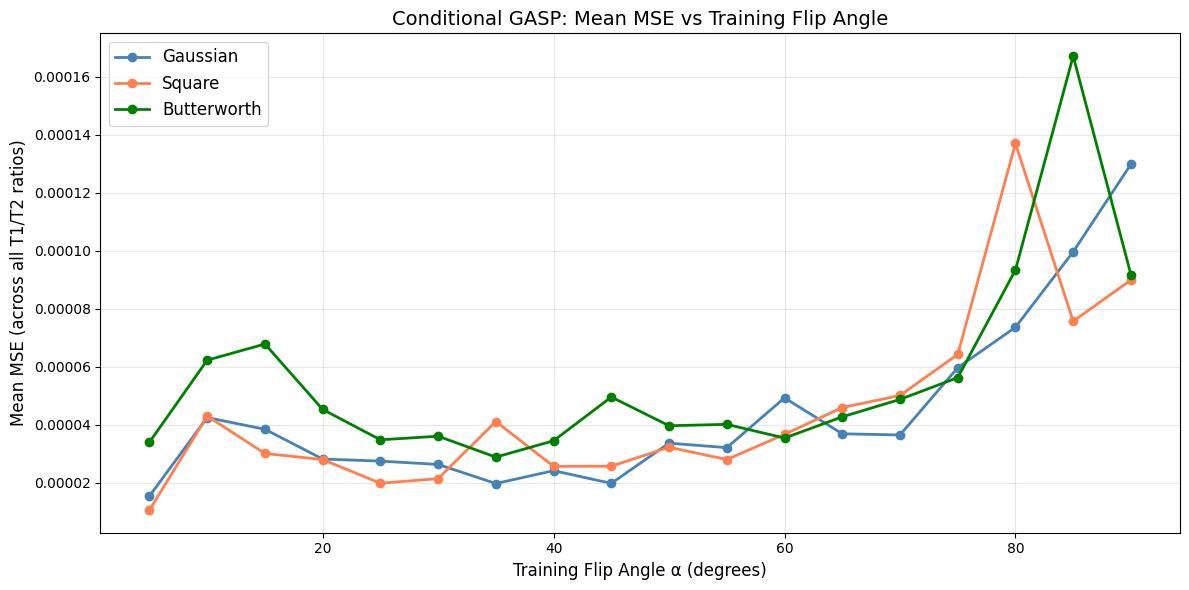


Optimal Flip Angles for Each Profile:
--------------------------------------------------
Profile         Optimal α       Min MSE        
--------------------------------------------------
Gaussian        5               0.000015       
Square          5               0.000011       
Butterworth     35              0.000029       


In [9]:
# Plot mean MSE vs alpha for each profile
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['steelblue', 'coral', 'green']
for idx, (name, res) in enumerate(results_profiles.items()):
    ax.plot(res['alphas'], res['mse_1d'], 'o-',
            label=name, color=colors[idx], linewidth=2, markersize=6)

ax.set_xlabel('Training Flip Angle α (degrees)', fontsize=12)
ax.set_ylabel('Mean MSE (across all T1/T2 ratios)', fontsize=12)
ax.set_title('Conditional GASP: Mean MSE vs Training Flip Angle', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print optimal alpha for each profile
print("\nOptimal Flip Angles for Each Profile:")
print("-" * 50)
print(f"{'Profile':<15} {'Optimal α':<15} {'Min MSE':<15}")
print("-" * 50)

for name, res in results_profiles.items():
    opt_idx = np.argmin(res['mse_1d'])
    opt_alpha = res['alphas'][opt_idx]
    min_mse = res['mse_1d'][opt_idx]
    print(f"{name:<15} {opt_alpha:<15.0f} {min_mse:<15.6f}")

### 1.4 MSE Statistics by Tissue Type

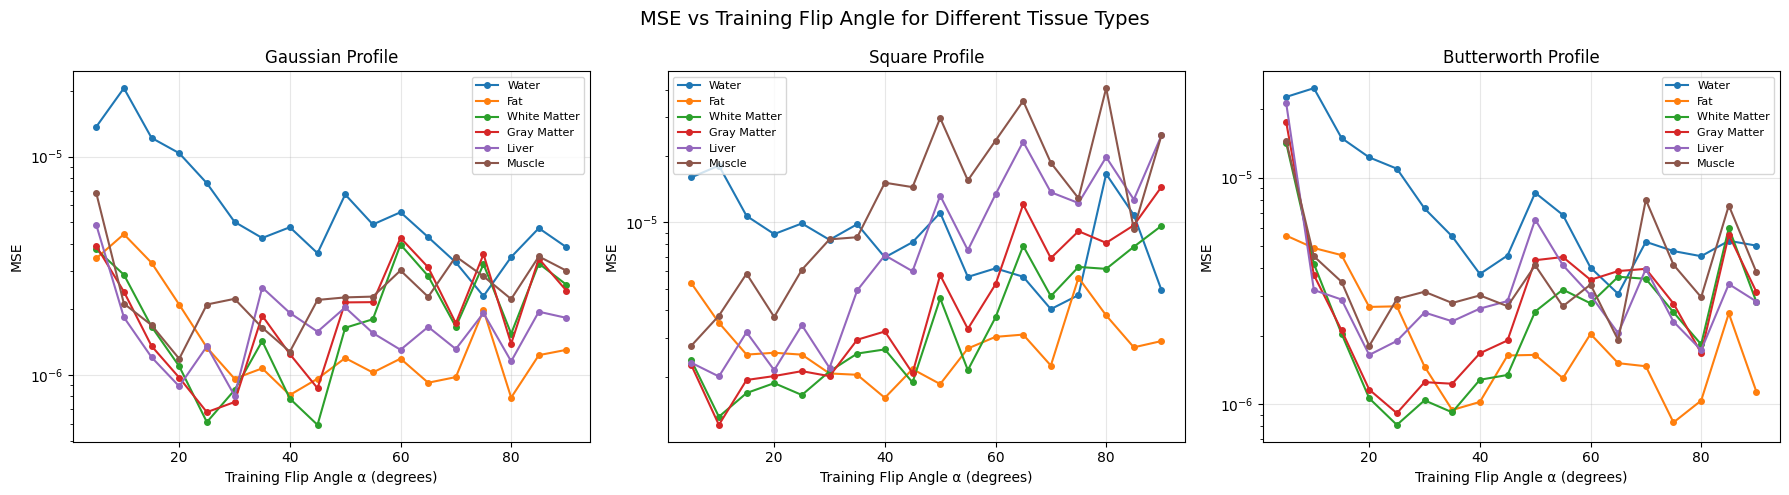

In [10]:
# Analyze performance for specific tissue types
# Find closest ratio index for each tissue
tissue_indices = {}
ratios = results_profiles['Gaussian']['ratios']

for tissue_name, props in TISSUE_TYPES.items():
    ratio = props['ratio']
    if ratio >= ratios.min() and ratio <= ratios.max():
        idx = np.argmin(np.abs(ratios - ratio))
        tissue_indices[tissue_name] = idx

# Plot MSE vs alpha for specific tissues
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for prof_idx, (prof_name, res) in enumerate(results_profiles.items()):
    ax = axes[prof_idx]
    
    for tissue_name, ratio_idx in tissue_indices.items():
        mse_tissue = res['mse_2d'][:, ratio_idx]
        ax.plot(res['alphas'], mse_tissue, 'o-', label=tissue_name, markersize=4)
    
    ax.set_xlabel('Training Flip Angle α (degrees)', fontsize=10)
    ax.set_ylabel('MSE', fontsize=10)
    ax.set_title(f'{prof_name} Profile', fontsize=12)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

plt.suptitle('MSE vs Training Flip Angle for Different Tissue Types', fontsize=14)
plt.tight_layout()
plt.show()

---
## 2. Analysis Summary

In [11]:
print("=" * 80)
print("CONDITIONAL GASP SENSITIVITY ANALYSIS SUMMARY")
print("=" * 80)

print("\n1. PROFILE COMPARISON:")
for name, res in results_profiles.items():
    mean_mse = res['mse_2d'].mean()
    std_mse = res['mse_2d'].std()
    opt_idx = np.argmin(res['mse_1d'])
    opt_alpha = res['alphas'][opt_idx]
    print(f"\n  {name} Profile:")
    print(f"    Overall mean MSE: {mean_mse:.6f} ± {std_mse:.6f}")
    print(f"    Optimal training α: {opt_alpha:.0f}° (MSE: {res['mse_1d'][opt_idx]:.6f})")

print("\n2. FLIP ANGLE SENSITIVITY:")
print("   - Conditional GASP models are sensitive to training flip angle")
print("   - Performance varies across different T1/T2 ratios")
print("   - Optimal α depends on target tissue distribution")

print("\n3. KEY OBSERVATIONS:")
print("   - Models trained at specific α generalize across T1/T2 ratios")
print("   - Different profiles may have different optimal training flip angles")
print("   - Consider training ensemble of models at different αs for robust performance")

print("\n4. RECOMMENDATIONS:")
best_profile = min(results_profiles.items(), key=lambda x: x[1]['mse_2d'].mean())
opt_idx = np.argmin(best_profile[1]['mse_1d'])
opt_alpha = best_profile[1]['alphas'][opt_idx]
print(f"   - Best profile: {best_profile[0]}")
print(f"   - Recommended training α: {opt_alpha:.0f}° for general use")
print(f"   - Method: {METHOD.upper()} with L2 regularization")

print("\n" + "=" * 80)

# Save results summary
summary_path = MODEL_DIR / 'sensitivity_summary.txt'
with open(summary_path, 'w') as f:
    f.write("CONDITIONAL GASP SENSITIVITY ANALYSIS SUMMARY\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Alpha values tested: {ALPHA_VALUES[0]} to {ALPHA_VALUES[-1]} degrees ({len(ALPHA_VALUES)} values)\n")
    f.write(f"T1/T2 ratios evaluated: {RATIO_MIN} to {RATIO_MAX} ({N_RATIO} values)\n")
    f.write(f"Method: {METHOD}\n")
    f.write(f"Latent dim: {LATENT_DIM}\n\n")
    
    for name, res in results_profiles.items():
        opt_idx = np.argmin(res['mse_1d'])
        f.write(f"{name} Profile:\n")
        f.write(f"  Mean MSE: {res['mse_2d'].mean():.6f}\n")
        f.write(f"  Optimal α: {res['alphas'][opt_idx]:.0f}°\n")
        f.write(f"  Min MSE: {res['mse_1d'][opt_idx]:.6f}\n\n")

print(f"\nSummary saved to: {summary_path}")

CONDITIONAL GASP SENSITIVITY ANALYSIS SUMMARY

1. PROFILE COMPARISON:

  Gaussian Profile:
    Overall mean MSE: 0.000044 ± 0.000290
    Optimal training α: 5° (MSE: 0.000015)

  Square Profile:
    Overall mean MSE: 0.000045 ± 0.000251
    Optimal training α: 5° (MSE: 0.000011)

  Butterworth Profile:
    Overall mean MSE: 0.000056 ± 0.000347
    Optimal training α: 35° (MSE: 0.000029)

2. FLIP ANGLE SENSITIVITY:
   - Conditional GASP models are sensitive to training flip angle
   - Performance varies across different T1/T2 ratios
   - Optimal α depends on target tissue distribution

3. KEY OBSERVATIONS:
   - Models trained at specific α generalize across T1/T2 ratios
   - Different profiles may have different optimal training flip angles
   - Consider training ensemble of models at different αs for robust performance

4. RECOMMENDATIONS:
   - Best profile: Gaussian
   - Recommended training α: 5° for general use
   - Method: AFFINE with L2 regularization


Summary saved to: /Users/mi